In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('dataset2.csv')

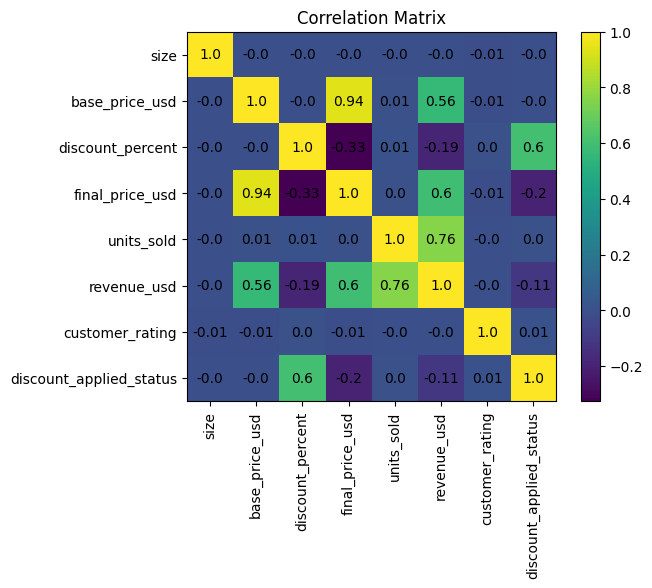

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# Compute correlation
corr = numeric_cols.corr()

# Plot heatmap
plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

# Add labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add values inside cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center')

plt.title("Correlation Matrix")
plt.show()

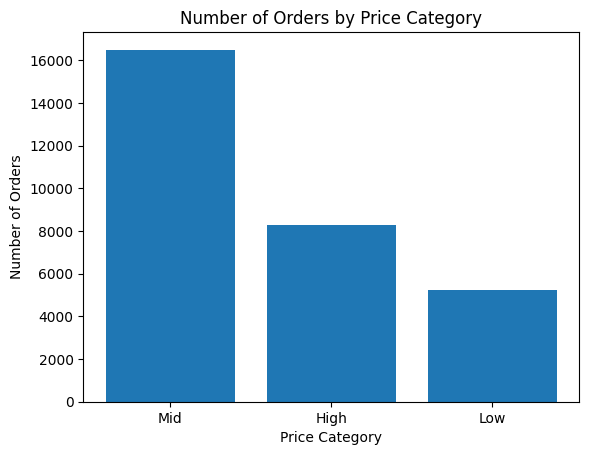

In [2]:
import matplotlib.pyplot as plt

# Count number of orders per price category
order_counts = df["price_category"].value_counts()

# Plot bar chart
plt.figure()
plt.bar(order_counts.index, order_counts.values)

# Labels and title
plt.xlabel("Price Category")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Price Category")

plt.show()

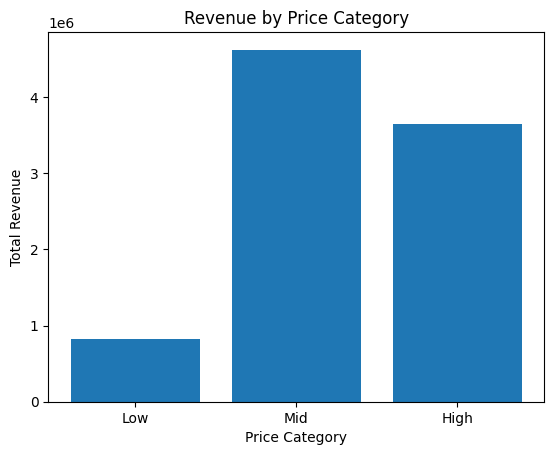

In [3]:
revenue_by_price = df.groupby("price_category")["revenue_usd"].sum().reindex(["Low", "Mid", "High"])

import matplotlib.pyplot as plt
plt.figure()
plt.bar(revenue_by_price.index, revenue_by_price.values)

plt.xlabel("Price Category")
plt.ylabel("Total Revenue")
plt.title("Revenue by Price Category")

plt.show()

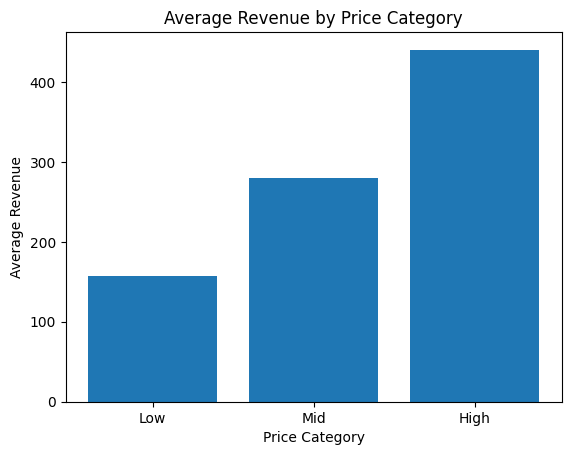

In [15]:
revenue_by_price = df.groupby("price_category")["revenue_usd"].mean().reindex(["Low", "Mid", "High"])

import matplotlib.pyplot as plt
plt.figure()
plt.bar(revenue_by_price.index, revenue_by_price.values)

plt.xlabel("Price Category")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Price Category")

plt.show()

In [24]:
from scipy.stats import f_oneway

groups = df.groupby("price_category")["revenue_usd"].apply(list)

f_stat, p = f_oneway(*groups)
print("{:.20e}".format(p))
print(f"p-value: {p:.5f}")
import numpy as np
print(np.format_float_scientific(p))

0.00000000000000000000e+00
p-value: 0.00000
0.e+00


## So, “There is a highly significant difference in revenue across price categories.”

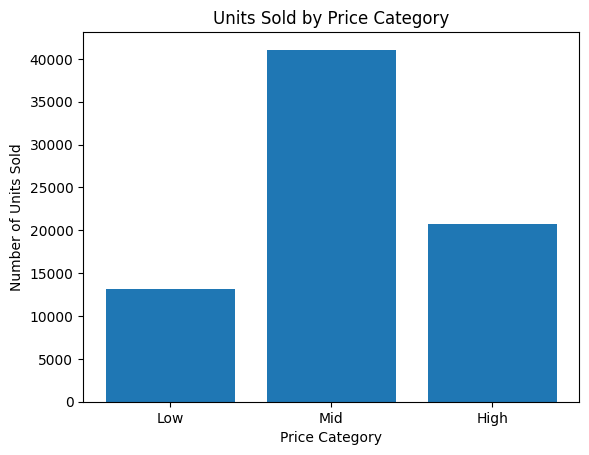

In [11]:
avg_units = df.groupby("price_category")["units_sold"].sum().reindex(["Low", "Mid", "High"])

plt.figure()
plt.bar(avg_units.index, avg_units.values)

plt.xlabel("Price Category")
plt.ylabel("Number of Units Sold")
plt.title("Units Sold by Price Category")

plt.show()

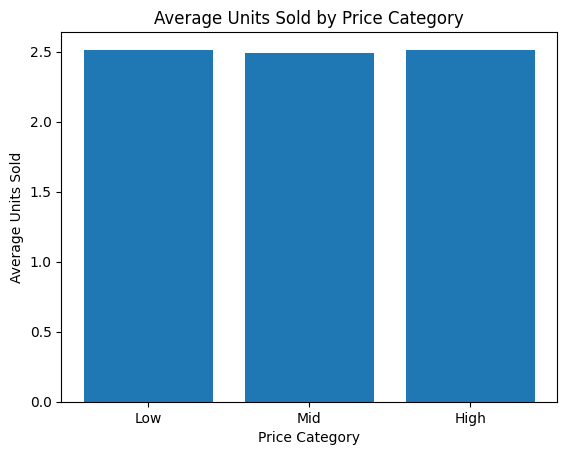

In [12]:
avg_units = df.groupby("price_category")["units_sold"].mean().reindex(["Low", "Mid", "High"])

plt.figure()
plt.bar(avg_units.index, avg_units.values)

plt.xlabel("Price Category")
plt.ylabel("Average Units Sold")
plt.title("Average Units Sold by Price Category")

plt.show()

In [9]:
from scipy.stats import f_oneway

groups = df.groupby("price_category")["units_sold"].apply(list)

f_stat, p = f_oneway(*groups)

print("p-value:", p)

p-value: 0.2173230033482881


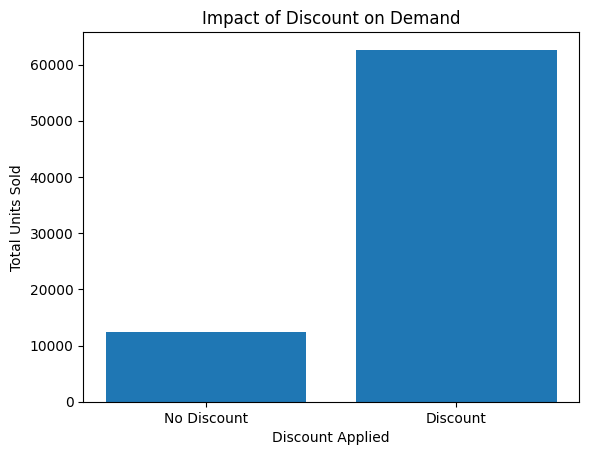

In [29]:
import matplotlib.pyplot as plt

avg_units = df.groupby("discount_applied_status")["units_sold"].sum()

plt.figure()
plt.bar(["No Discount", "Discount"], avg_units.values)

plt.xlabel("Discount Applied")
plt.ylabel("Total Units Sold")
plt.title("Impact of Discount on Demand")

plt.show()

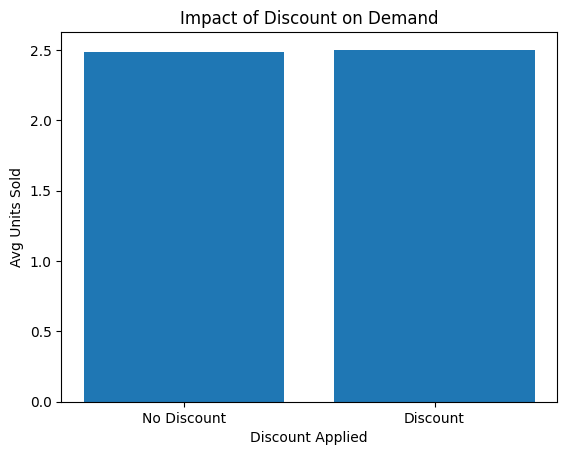

In [28]:
import matplotlib.pyplot as plt

avg_units = df.groupby("discount_applied_status")["units_sold"].mean()

plt.figure()
plt.bar(["No Discount", "Discount"], avg_units.values)

plt.xlabel("Discount Applied")
plt.ylabel("Avg Units Sold")
plt.title("Impact of Discount on Demand")

plt.show()

In [ ]:
from scipy.stats import ttest_ind

no_disc = df[df["discount_applied_status"] == 0]["units_sold"]
disc = df[df["discount_applied_status"] == 1]["units_sold"]

t_stat, p = ttest_ind(disc, no_disc)

print("p-value:", p)
## “Discount increases total demand, but not because customers buy more per order.”

p-value: 0.3867445850357707


In [33]:
from scipy.stats import chi2_contingency
import pandas as pd

# Count orders
table = pd.DataFrame({
    "Count": df["discount_applied_status"].value_counts()
})

print(table)

                         Count
discount_applied_status       
1                        25029
0                         4971


In [34]:
# Observed counts
observed = df["discount_applied_status"].value_counts().values

# Expected counts (equal distribution assumption)
expected = [len(df)/2, len(df)/2]

# Create table
contingency_table = [observed, expected]

In [ ]:
chi2, p, dof, exp = chi2_contingency(contingency_table)

print("p-value:", p)
## “Chi-square test shows that the distribution of orders between discounted and non-discounted products is significantly different, 
# indicating that discounts are associated with higher order volume.”

p-value: 0.0


In [31]:
from scipy.stats import ttest_ind

no_disc = df[df["discount_applied_status"] == 0]["revenue_usd"]
disc = df[df["discount_applied_status"] == 1]["revenue_usd"]

t_stat, p = ttest_ind(disc, no_disc)

print("p-value:", p)

p-value: 7.867778820335429e-81
